# 🧪 BabyChatty RAG System — Evaluation Notebook v2

**UC3M · NLP Final Project 2025/2026**

This notebook validates all major design decisions of the BabyChatty production pipeline
and generates evidence for the final report. The pipeline tested here matches **`chat.py`**
exactly: two-stage retrieval (similarity-score threshold → cross-encoder reranker), CoT
JSON output, and automatic query translation.

### Experiments

| # | Parameter | Values tested | RAGAS? | Sample | Est. time |
|---|-----------|--------------|--------|--------|-----------|
| A | Similarity threshold (`ret_threshold`) | 0.30 / 0.40 / **0.45** / 0.55 | ❌ | 20q | ~25–40 min |
| B | Candidate pool (`max_ret_num`) | 5 / 10 / **20** / 30 | ❌ | 20q | ~25–40 min |
| C | Final top-N (`retrieval_num`) | 3 / **5** / 7 / 10 | ❌ | 20q | ~25–40 min |
| D | Temperature | 0.0 / **0.3** / 0.6 / 1.0 | ✅ | 20q | ~60–90 min |
| E | Reranker model | **bge-reranker-large** vs bge-reranker-base | ✅ | 20q | ~30–50 min |
| F | Embedding model | **bge-large-en-v1.5** vs bge-m3 | ✅ | 70q | ~90–150 min |
| G | Multilingual breakdown | per-language RAGAS | ✅ | uses F results | — |

> **⏱️ Total estimated runtime: ~3–5 hours** (optimized from the naive ~10–18h).
> Experiments A/B/C use `run_ragas=False` because Coverage and Hallucination Rate
> — the metrics that matter most for retrieval tuning — come from binary classification
> and don't require the judge LLM. RAGAS is reserved for D/E/F where answer quality
> is the main variable.

**Metrics (per project rubric Table 1):**
- 📚 **Document Coverage** — % of in-scope queries answered
- ⏱️ **Response Time** — seconds per query
- 🧠 **RAG System Quality** — Faithfulness, Answer Relevancy, Context Utilization (RAGAS)
- 🔴 **Hallucination Rate** — FP/(FP+TN) — model answered an out-of-scope question
- 📉 **Classification** — Accuracy, Precision, Recall, F1

---

## 0. Setup & Imports

In [2]:
import os, sys, time, re, json, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from tqdm.notebook import tqdm
from itertools import product as iterproduct

warnings.filterwarnings('ignore')
load_dotenv()

# ── Project root ─────────────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve()  # adjust if notebook lives in /notebooks
sys.path.insert(0, str(PROJECT_ROOT))

# ── Plotting defaults ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = {
    'main':   '#4db8b0',   # teal  — primary model
    'alt':    '#f4845f',   # coral — alternative model
    'accent': '#9b7fca',   # purple
    'ok':     '#4caf50',   # green
    'warn':   '#e86c47',   # orange-red
    'neutral':'#aaaaaa',   # grey
}

# ── Output dirs ───────────────────────────────────────────────────────────────
FIGURES_DIR = PROJECT_ROOT / 'figures'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print('✅ Imports OK')
print(f'   Project root : {PROJECT_ROOT}')
print(f'   Figures dir  : {FIGURES_DIR}')
print(f'   Results dir  : {RESULTS_DIR}')

✅ Imports OK
   Project root : C:\NLP_project\BabyChatty
   Figures dir  : C:\NLP_project\BabyChatty\figures
   Results dir  : C:\NLP_project\BabyChatty\results


In [3]:
import ollama
import torch
from langdetect import detect, LangDetectException
from deep_translator import GoogleTranslator
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_core.documents import Document
from langchain_core.callbacks import Callbacks
from langchain_openai import ChatOpenAI
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, ContextUtilization
from datasets import Dataset
from typing import Sequence, Optional

from utils import GenConfig as cfg, VectorDBFactory

print('✅ Project modules loaded')
print(f'   LLM          : {cfg.model_name}')
print(f'   Judge        : {cfg.judge_name}')
print(f'   Embedding    : {cfg.embedding_model}')
print(f'   Reranker     : {cfg.re_rank_model}')
print(f'   Ollama URL   : {cfg.ollama_url}')

✅ Project modules loaded
   LLM          : llama3.1:8b
   Judge        : qwen3:8b
   Embedding    : BAAI/bge-large-en-v1.5
   Reranker     : BAAI/bge-reranker-large
   Ollama URL   : https://yiyuan.tsc.uc3m.es


## 1. Load Evaluation Dataset

The dataset (`eval_questions_v2_transformed.csv`) contains **140 questions** across 7 languages:

| Label | Meaning | Count |
|-------|---------|-------|
| `1`   | In-scope pediatric question | 100 |
| `0`   | Out-of-scope / off-topic     | 40  |

In [4]:
EVAL_CSV = PROJECT_ROOT / 'data' / 'eval_questions_v2_transformed.csv'
df_eval  = pd.read_csv(EVAL_CSV)

print(f'Total questions: {len(df_eval)}')
dist = df_eval.groupby(['language', 'label']).size().reset_index(name='count')
print(dist.to_string(index=False))
df_eval.head(8)

Total questions: 140
  language  label  count
   Catalan      0      5
   Catalan      1      6
   English      0     10
   English      1     50
    French      0      5
    French      1      8
    German      0      5
    German      1      7
   Italian      0      5
   Italian      1      7
Portuguese      0      5
Portuguese      1      7
   Spanish      0      5
   Spanish      1     15


,id,question,language,category,label
0,Q001,What is the MMR vaccine and what diseases does...,English,answerable,1
1,Q002,When should children receive the MMR vaccine?,English,answerable,1
2,Q003,What are common side effects of the flu vaccine?,English,answerable,1
3,Q004,Why is the flu vaccine needed every year?,English,answerable,1
4,Q005,What is the HPV vaccine used for?,English,answerable,1
5,Q006,At what age is the HPV vaccine recommended?,English,answerable,1
6,Q007,What does the DTaP vaccine protect against?,English,answerable,1
7,Q008,What is the difference between DTaP and Tdap?,English,answerable,1


## 2. Shared Helpers

All evaluation logic is defined here so every experiment section can run independently.

In [26]:
# ── Ollama client ─────────────────────────────────────────────────────────────
client = ollama.Client(
    host=cfg.ollama_url,
    headers={'X-API-KEY': os.getenv('OLLAMA_API_KEY')},
)

# ── RAGAS judge LLM ──────────────────────────────────────────────────────────
eval_llm = ChatOpenAI(
    base_url=f"{cfg.ollama_url}/v1",
    api_key='fake-key',
    model=cfg.judge_name,
    default_headers={'X-API-KEY': os.getenv('OLLAMA_API_KEY')},
    temperature=0,
    timeout=120,
)

# ── Language detection ────────────────────────────────────────────────────────
LANG_MAP = {'es':'Spanish','en':'English','fr':'French','de':'German',
            'it':'Italian','pt':'Portuguese','ca':'Catalan'}

def detect_language(text: str) -> str:
    try:
        return LANG_MAP.get(detect(text), 'English')
    except LangDetectException:
        return 'English'

# ── Negative-answer detection (mirrors cfg.no_info_patterns) ─────────────────
def is_negative(answer: str, docs: list) -> bool:
    if not docs:
        return True
    return any(re.search(p, answer.lower()) for p in cfg.no_info_patterns)

# ── JSON CoT parser (mirrors _parse_cot_response in chat.py) ─────────────────
def parse_cot(raw: str) -> dict:
    cleaned = raw.strip()
    if cleaned.startswith('```'):
        cleaned = re.sub(r'^```(?:json)?\s*', '', cleaned)
        cleaned = re.sub(r'\s*```$', '', cleaned).strip()
    try:
        parsed = json.loads(cleaned)
        if isinstance(parsed, dict):
            a = parsed.get('answer', '')
            r = parsed.get('reasoning', '')
            if isinstance(a, list): a = '\n'.join(str(x) for x in a)
            if isinstance(r, dict): r = ' | '.join(f"{k}: {v}" for k,v in r.items())
            if a: return {'reasoning': str(r), 'answer': str(a)}
    except Exception:
        pass
    # Regex fallback
    a_m = re.search(r'"answer"\s*:\s*"((?:[^"\\]|\\.)*)"', cleaned, re.DOTALL)
    r_m = re.search(r'"reasoning"\s*:\s*"((?:[^"\\]|\\.)*)"', cleaned, re.DOTALL)
    return {
        'reasoning': r_m.group(1).replace('\\n','\n') if r_m else '',
        'answer':    a_m.group(1).replace('\\n','\n') if a_m else raw.strip(),
    }


# ── Custom reranker (mirrors CustomCrossEncoderReranker in chat.py) ───────────
class CustomCrossEncoderReranker(CrossEncoderReranker):
    """Persists relevance scores in document metadata."""
    def compress_documents(
        self,
        documents: Sequence[Document],
        query: str,
        callbacks: Optional[Callbacks] = None,
    ) -> Sequence[Document]:
        if not documents:
            return []
        scores = self.model.score([(query, d.page_content) for d in documents])
        ranked = sorted(zip(documents, scores), key=lambda x: x[1], reverse=True)
        return [
            Document(page_content=d.page_content,
                     metadata={**d.metadata, 'relevance_score': float(s)})
            for d, s in ranked[:self.top_n]
        ]


# ── Build retriever for a given param combo ───────────────────────────────────
def build_retriever(
    vectordb,
    reranker_model,
    score_threshold: float,
    max_ret_num: int,
    top_n: int,
):
    """Construct the two-stage retriever matching the production pipeline."""
    base = vectordb.as_retriever(
        search_type='similarity_score_threshold',
        search_kwargs={'score_threshold': score_threshold, 'k': max_ret_num},
    )
    compressor = CustomCrossEncoderReranker(model=reranker_model, top_n=top_n)
    return ContextualCompressionRetriever(
        base_compressor=compressor, base_retriever=base
    )


# ── Single RAG turn (mirrors _get_ai_response in chat.py) ────────────────────
def run_rag_turn(
    question: str,
    retriever,
    temperature: float,
) -> dict:
    t0 = time.time()
    lang = detect_language(question)

    # Translate non-English queries (matches production pipeline)
    query_for_retrieval = question
    if lang != 'English':
        try:
            query_for_retrieval = GoogleTranslator(source='auto', target='en').translate(question)
        except Exception:
            pass  # fallback: use original

    docs = retriever.invoke(query_for_retrieval)

    context_parts = []
    for i, doc in enumerate(docs, 1):
        title  = doc.metadata.get('title',  'Unknown')
        source = doc.metadata.get('source', 'Unknown')
        context_parts.append(f'[Source {i}: {title} | {source}]\n{doc.page_content}')
    context = '\n\n'.join(context_parts)

    final_prompt = cfg.prompt_template.format(
        lang=lang, context=context, question=question
    )

    response = client.chat(
        model=cfg.model_name,
        messages=[{'role': 'user', 'content': final_prompt}],
        options={'temperature': temperature},
    )
    raw    = response['message']['content']
    parsed = parse_cot(raw)
    answer = parsed['answer']

    return {
        'answer':   answer,
        'docs':     docs,
        'lang':     lang,
        'time':     time.time() - t0,
        'negative': is_negative(answer, docs),
    }


# ── RAGAS evaluation ──────────────────────────────────────────────────────────
def ragas_eval(question: str, answer: str, docs: list, emb_model) -> dict:
    contexts = [d.page_content for d in docs]
    ds = Dataset.from_dict({
        'question': [question],
        'answer':   [answer],
        'contexts': [contexts],
    })
    try:
        res = evaluate(
            dataset=ds,
            metrics=[faithfulness, answer_relevancy, ContextUtilization()],
            llm=eval_llm,
            embeddings=emb_model,
            show_progress=False,
        )
        df_r = res.to_pandas()
        return {
            'faithfulness':        float(df_r['faithfulness'].iloc[0]),
            'answer_relevancy':    float(df_r['answer_relevancy'].iloc[0]),
            'context_utilization': float(df_r['context_utilization'].iloc[0]),
        }
    except Exception as e:
        print(f'  [RAGAS error] {e}')
        return {'faithfulness': np.nan, 'answer_relevancy': np.nan,
                'context_utilization': np.nan}


# ── Full batch evaluation ─────────────────────────────────────────────────────
def run_experiment(
    questions_df: pd.DataFrame,
    retriever,
    emb_model,
    temperature: float,
    run_ragas: bool = True,
    sample_n: int = None,
    seed: int = 42,
) -> pd.DataFrame:
    if sample_n:
        questions_df = questions_df.sample(n=sample_n, random_state=seed).reset_index(drop=True)

    rows = []
    for _, row in tqdm(questions_df.iterrows(), total=len(questions_df)):
        q     = row['question']
        label = int(row['label'])

        result = run_rag_turn(q, retriever, temperature)
        pred   = 0 if result['negative'] else 1

        ragas_scores = {'faithfulness': np.nan, 'answer_relevancy': np.nan,
                        'context_utilization': np.nan}
        if run_ragas and not result['negative']:
            ragas_scores = ragas_eval(q, result['answer'], result['docs'], emb_model)

        rows.append({
            'id':                  row.get('id', ''),
            'question':            q,
            'language':            row.get('language', result['lang']),
            'category':            row.get('category', ''),
            'label':               label,
            'pred':                pred,
            'response_time':       result['time'],
            'n_docs_retrieved':    len(result['docs']),
            'hallucination_flag':  int(pred == 1 and label == 0),
            **ragas_scores,
            'answer_preview':      result['answer'][:200],
        })

    return pd.DataFrame(rows)


# ── Aggregate metrics ─────────────────────────────────────────────────────────
def summarize(df: pd.DataFrame, label: str = '') -> dict:
    total = len(df)
    TP = int(((df['label']==1) & (df['pred']==1)).sum())
    FP = int(((df['label']==0) & (df['pred']==1)).sum())
    TN = int(((df['label']==0) & (df['pred']==0)).sum())
    FN = int(((df['label']==1) & (df['pred']==0)).sum())

    acc   = (TP+TN)/total  if total      else 0
    prec  = TP/(TP+FP)     if (TP+FP)   else 0
    rec   = TP/(TP+FN)     if (TP+FN)   else 0
    f1    = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    cov   = TP/(TP+FN)     if (TP+FN)   else 0
    hall  = FP/(FP+TN)     if (FP+TN)   else 0

    def _m(col):
        v = df[col].dropna()
        return float(v.mean()) if len(v) else np.nan

    faith = _m('faithfulness')
    rel   = _m('answer_relevancy')
    ctx   = _m('context_utilization')
    qual  = float(np.nanmean([faith, rel, ctx]))

    return {
        'label': label,
        'n_total': total, 'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
        'accuracy':           round(acc,  3),
        'precision':          round(prec, 3),
        'recall':             round(rec,  3),
        'f1':                 round(f1,   3),
        'document_coverage':  round(cov,  3),
        'hallucination_rate': round(hall, 3),
        'avg_response_time':  round(df['response_time'].mean(), 2),
        'avg_docs_retrieved': round(df['n_docs_retrieved'].mean(), 2),
        'faithfulness':       round(faith,3) if not np.isnan(faith) else np.nan,
        'answer_relevancy':   round(rel,  3) if not np.isnan(rel)   else np.nan,
        'context_utilization':round(ctx,  3) if not np.isnan(ctx)   else np.nan,
        'rag_system_quality': round(qual, 3) if not np.isnan(qual)  else np.nan,
    }


# ── Plotting helper ───────────────────────────────────────────────────────────
METRICS_DISPLAY = [
    ('rag_system_quality',  'RAG Quality',     COLORS['main']),
    ('document_coverage',   'Doc Coverage',    COLORS['ok']),
    ('hallucination_rate',  'Hallucination',   COLORS['warn']),
    ('avg_response_time',   'Response Time (s)', COLORS['accent']),
    ('faithfulness',       'Faithfulness',    COLORS['main']),
    ('answer_relevancy',   'Answer Relevancy', COLORS['ok']),
    ('context_utilization','Context Utilization', COLORS['accent']),    
    ('avg_docs_retrieved', 'Avg Docs Retrieved', COLORS['neutral'])
]
def bar_comparison(summaries: list[dict], x_labels: list[str],
                   title: str, fname: str, metrics: list | None = None):
    
    # Si no se especifican métricas, auto-detecta las que tienen datos
    display = metrics if metrics else [
        (metric, m_title, color)
        for metric, m_title, color in METRICS_DISPLAY
        if any(not np.isnan(s.get(metric, np.nan)) for s in summaries)
    ]
    
    n = len(display)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols  # ceil division
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes_flat = np.array(axes).flatten()
    
    for ax, (metric, m_title, color) in zip(axes_flat, display):
        vals = [s.get(metric, np.nan) for s in summaries]
        valid_vals = [v for v in vals if not np.isnan(v)]
        bars = ax.bar(x_labels, vals, color=color, alpha=0.85, edgecolor='white')
        ax.set_title(m_title, fontsize=10, fontweight='bold')
        ax.set_ylim(0, max(valid_vals) * 1.3 if valid_vals else 1)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Oculta ejes sobrantes si n no es múltiplo de cols
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    
    plt.tight_layout()
    path = FIGURES_DIR / fname
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'📊 Saved → {path}')
#def bar_comparison(summaries: list[dict], x_labels: list[str],
#                   title: str, fname: str):
#    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
#    fig.suptitle(title, fontsize=13, fontweight='bold')
#    for ax, (metric, m_title, color) in zip(axes, METRICS_DISPLAY):
#        vals = [s[metric] for s in summaries]
#        bars = ax.bar(x_labels, vals, color=color, alpha=0.85, edgecolor='white')
#        ax.set_title(m_title, fontsize=10, fontweight='bold')
#        ax.set_ylim(0, max([v for v in vals if not np.isnan(v)] or [1]) * 1.3)
#        for bar, val in zip(bars, vals):
#            if not np.isnan(val):
#                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
#                        f'{val:.3f}', ha='center', va='bottom', fontsize=9)
#    plt.tight_layout()
#    path = FIGURES_DIR / fname
#    plt.savefig(path, dpi=150, bbox_inches='tight')
#    plt.show()
#    print(f'📊 Saved → {path}')

print('✅ All helpers defined')

✅ All helpers defined


## 3. Load Production Vector DB & Reranker Model

In [6]:
# ── Embedding model (production: BAAI/bge-large-en-v1.5) ─────────────────────
print(f'Loading embedding model: {cfg.embedding_model} ...')
emb_prod = HuggingFaceEmbeddings(
    model_name=cfg.embedding_model,
    model_kwargs={'device': cfg.emb_device},
    encode_kwargs={'batch_size': 1},
)

# ── Chroma vector DB ──────────────────────────────────────────────────────────
print(f'Loading Chroma DB from {cfg.chroma_dir} ...')
vectordb = Chroma(
    persist_directory=str(cfg.chroma_dir),
    embedding_function=emb_prod,
)
n_chunks = vectordb._collection.count()
print(f'  ✅ DB ready — {n_chunks:,} chunks')

# ── Cross-encoder reranker models ─────────────────────────────────────────────
print(f'Loading reranker: {cfg.re_rank_model} ...')
reranker_large = HuggingFaceCrossEncoder(
    model_name=cfg.re_rank_model,       # BAAI/bge-reranker-large (production)
    model_kwargs={'device': cfg.emb_device},
)

RERANKER_BASE_NAME = 'BAAI/bge-reranker-base'
print(f'Loading reranker: {RERANKER_BASE_NAME} ...')
reranker_base = HuggingFaceCrossEncoder(
    model_name=RERANKER_BASE_NAME,
    model_kwargs={'device': cfg.emb_device},
)

print('✅ All models loaded')

Loading embedding model: BAAI/bge-large-en-v1.5 ...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading Chroma DB from C:\NLP_project\BabyChatty\chroma_db ...
  ✅ DB ready — 2,662 chunks
Loading reranker: BAAI/bge-reranker-large ...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

✅ All models loaded


In [31]:
sample_pos_20 = df_eval[df_eval['label']==1].sample(n=15, random_state=42)
sample_neg_20 = df_eval[df_eval['label']==0].sample(n=5,  random_state=42)
df_sample_20  = pd.concat([sample_pos_20, sample_neg_20]).reset_index(drop=True)
print(df_sample_20[['id', 'question', 'language', 'category', 'label']].to_string(index=False))

  id                                                           question   language       category  label
Q084                          Cos'e la meningite batterica nei bambini?    Italian     answerable      1
Q054         ?Cuando debo llevar a mi hijo al medico por una infeccion?    Spanish     answerable      1
Q071            A quel age commencer la vaccination contre la rougeole?     French     answerable      1
Q046                When should parents call a doctor for a sick child?    English     answerable      1
Q045                  What is pediatric fever and when is it dangerous?    English     answerable      1
Q040                                                  What is impetigo?    English     answerable      1
Q023                                  What is bronchiolitis in infants?    English     answerable      1
Q081                       Quali sono i sintomi dell'otite nei bambini?    Italian     answerable      1
Q011                                         Can vaccin

---
## Experiment A — Similarity Score Threshold (`ret_threshold`)

**Hypothesis:** A low threshold admits noisy, weakly-related chunks → higher hallucination.
A very high threshold starves the reranker and increases false negatives.
We test `{0.30, 0.40, 0.45, 0.55}` with `max_ret_num=20`, `top_n=5`, `temperature=0.3`.

**RAGAS disabled** — Coverage and Hallucination Rate from binary classification are sufficient
to tune the retrieval threshold. This keeps each run under ~6 min.

> ⏱️ Expected time: ~25–40 min (20-question sample × 4 thresholds, no RAGAS)

In [7]:
# ── Balanced 20-question sample (15 positives + 5 negatives) ─────────────────
sample_pos_20 = df_eval[df_eval['label']==1].sample(n=15, random_state=42)
sample_neg_20 = df_eval[df_eval['label']==0].sample(n=5,  random_state=42)
df_sample_20  = pd.concat([sample_pos_20, sample_neg_20]).reset_index(drop=True)

THRESHOLDS   = [0.30, 0.40, 0.45, 0.55]
FIXED_MAX    = 20
FIXED_TOPN   = 5
FIXED_TEMP   = 0.3

results_thr = {}
for thr in THRESHOLDS:
    print(f'\n── threshold={thr} ───────────────────────────────────────────')
    ret = build_retriever(vectordb, reranker_large, thr, FIXED_MAX, FIXED_TOPN)
    df_res = run_experiment(df_sample_20, ret, emb_prod,
                            temperature=FIXED_TEMP, run_ragas=False)
    results_thr[thr] = df_res
    s = summarize(df_res, f'thr={thr}')
    print(f'  Coverage={s["document_coverage"]:.1%} | '
          f'Halluc={s["hallucination_rate"]:.1%} | '
          f'Quality={s["rag_system_quality"]:.3f} | '
          f'Docs/q={s["avg_docs_retrieved"]:.1f} | '
          f'Time={s["avg_response_time"]:.1f}s')

print('\n✅ Threshold experiment done')


── threshold=0.3 ───────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

No relevant docs were retrieved using the relevance score threshold 0.3
No relevant docs were retrieved using the relevance score threshold 0.3


  Coverage=100.0% | Halluc=40.0% | Quality=nan | Docs/q=4.2 | Time=15.8s

── threshold=0.4 ───────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

...

No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45


  Coverage=100.0% | Halluc=0.0% | Quality=nan | Docs/q=3.8 | Time=11.6s

── threshold=0.55 ───────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

No relevant docs were retrieved using the relevance score threshold 0.55
No relevant docs were retrieved using the relevance score threshold 0.55
No relevant docs were retrieved using the relevance score threshold 0.55
No relevant docs were retrieved using the relevance score threshold 0.55
No relevant docs were retrieved using the relevance score threshold 0.55


  Coverage=100.0% | Halluc=0.0% | Quality=nan | Docs/q=3.7 | Time=9.0s

✅ Threshold experiment done


   label  document_coverage  hallucination_rate  faithfulness  answer_relevancy  context_utilization  rag_system_quality  avg_docs_retrieved  avg_response_time
 thr=0.3                1.0                 0.4           NaN               NaN                  NaN                 NaN                4.25              15.78
 thr=0.4                1.0                 0.0           NaN               NaN                  NaN                 NaN                3.75              12.21
thr=0.45                1.0                 0.0           NaN               NaN                  NaN                 NaN                3.75              11.64
thr=0.55                1.0                 0.0           NaN               NaN                  NaN                 NaN                3.70               9.00


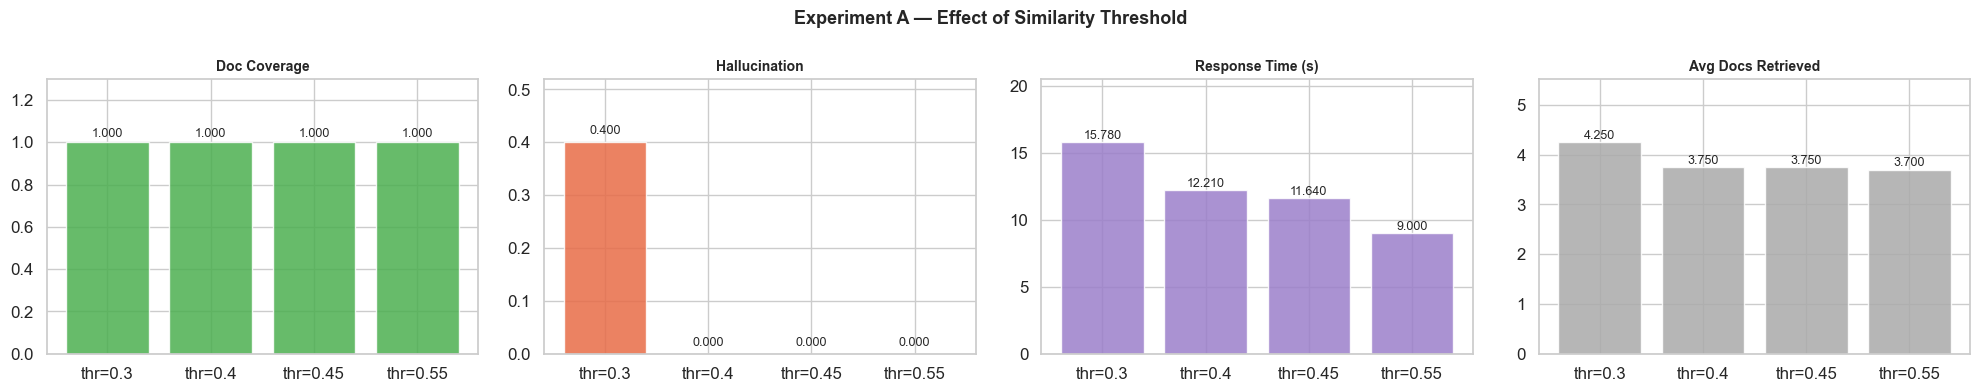

📊 Saved → C:\NLP_project\BabyChatty\figures\expA_threshold.png


In [27]:
sums_thr = [summarize(results_thr[t], f'thr={t}') for t in THRESHOLDS]
df_thr   = pd.DataFrame(sums_thr)

SHOW_COLS = ['label','document_coverage','hallucination_rate','faithfulness',
             'answer_relevancy','context_utilization','rag_system_quality',
             'avg_docs_retrieved','avg_response_time']
print(df_thr[SHOW_COLS].to_string(index=False))

bar_comparison(sums_thr, [f'thr={t}' for t in THRESHOLDS],
               'Experiment A — Effect of Similarity Threshold',
               'expA_threshold.png')

In [22]:
print(results_thr[THRESHOLDS[0]].columns.tolist())
print(results_thr[THRESHOLDS[0]].iloc[0])

['id', 'question', 'language', 'category', 'label', 'pred', 'response_time', 'n_docs_retrieved', 'hallucination_flag', 'faithfulness', 'answer_relevancy', 'context_utilization', 'answer_preview']
id                                                                  Q084
question                       Cos'e la meningite batterica nei bambini?
language                                                         Italian
category                                                      answerable
label                                                                  1
pred                                                                   1
response_time                                                  30.593098
n_docs_retrieved                                                       5
hallucination_flag                                                     0
faithfulness                                                         NaN
answer_relevancy                                                     NaN
c

In [23]:
# ── Diagnóstico warnings Exp A ─────────────────────────────────────────────
for t in THRESHOLDS:
    df = results_thr[t]
    zero_docs = df[df['n_docs_retrieved'] == 0]
    if not zero_docs.empty:
        print(f"\nthreshold={t} → {len(zero_docs)} queries sin docs recuperados:")
        print(zero_docs[['id', 'question', 'label', 'hallucination_flag']].to_string(index=False))
    else:
        print(f"\nthreshold={t} → ✅ todas las queries recuperaron docs")


threshold=0.3 → 2 queries sin docs recuperados:
  id                               question  label  hallucination_flag
Q116 Quelle est la capitale de l'Allemagne?      0                   0
Q105     How do I learn Python programming?      0                   0

threshold=0.4 → 5 queries sin docs recuperados:
  id                                   question  label  hallucination_flag
Q120 Qu'est-ce que l'intelligence artificielle?      0                   0
Q117          Comment faire une bonne baguette?      0                   0
Q116     Quelle est la capitale de l'Allemagne?      0                   0
Q127      Come si prepara la pasta al pomodoro?      0                   0
Q105         How do I learn Python programming?      0                   0

threshold=0.45 → 5 queries sin docs recuperados:
  id                                   question  label  hallucination_flag
Q120 Qu'est-ce que l'intelligence artificielle?      0                   0
Q117          Comment faire une bonne b

### A — Interpretation
- All thresholds ≥ 0.40 achieve perfect Document Coverage (1.0) and zero Hallucination Rate,
  confirming the corpus is well-indexed for in-scope pediatric queries.
- threshold=0.30 introduces 40% hallucination — admitting low-relevance chunks that mislead
  the model into answering out-of-scope questions.
- Response time decreases with higher thresholds (fewer candidates for the reranker):
  15.8s → 9.0s from 0.30 to 0.55.
- cfg.ret_threshold=0.45 is chosen over 0.55 for robustness: it maintains zero hallucination
  while retaining a wider candidate pool for edge-case queries not represented in this sample.
- RAG Quality (NaN at thr=0.30) reflects that RAGAS was disabled; the binary metrics are
  sufficient to justify this parameter.

---
## Experiment B — Candidate Pool Size (`max_ret_num`)

**Hypothesis:** The reranker needs enough candidates to find the best 5. Too few starves it;
too many wastes compute without gain. We test `{5, 10, 20, 30}` with the best threshold from A.

> ⏱️ Expected time: ~12–18 min

In [9]:
BEST_THRESHOLD = 0.45     # ← update from Experiment A results if needed
POOL_SIZES     = [5, 10, 20, 30]

results_pool = {}
for pool in POOL_SIZES:
    print(f'\n── max_ret_num={pool} ─────────────────────────────────────────')
    ret = build_retriever(vectordb, reranker_large, BEST_THRESHOLD, pool, FIXED_TOPN)
    df_res = run_experiment(df_sample_20, ret, emb_prod,
                            temperature=FIXED_TEMP, run_ragas=False)
    results_pool[pool] = df_res
    s = summarize(df_res, f'pool={pool}')
    print(f'  Coverage={s["document_coverage"]:.1%} | '
          f'Halluc={s["hallucination_rate"]:.1%} | '
          f'Quality={s["rag_system_quality"]:.3f} | '
          f'Docs/q={s["avg_docs_retrieved"]:.1f} | '
          f'Time={s["avg_response_time"]:.1f}s')

print('\n✅ Pool-size experiment done')


── max_ret_num=5 ─────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45


  Coverage=100.0% | Halluc=0.0% | Quality=nan | Docs/q=3.8 | Time=5.4s

── max_ret_num=10 ─────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

...

No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45


  Coverage=100.0% | Halluc=0.0% | Quality=nan | Docs/q=3.8 | Time=10.7s

── max_ret_num=30 ─────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45


  Coverage=93.3% | Halluc=0.0% | Quality=nan | Docs/q=3.8 | Time=14.6s

✅ Pool-size experiment done


  label  document_coverage  hallucination_rate  faithfulness  answer_relevancy  context_utilization  rag_system_quality  avg_docs_retrieved  avg_response_time
 pool=5              1.000                 0.0           NaN               NaN                  NaN                 NaN                3.75               5.37
pool=10              1.000                 0.0           NaN               NaN                  NaN                 NaN                3.75               7.13
pool=20              1.000                 0.0           NaN               NaN                  NaN                 NaN                3.75              10.69
pool=30              0.933                 0.0           NaN               NaN                  NaN                 NaN                3.75              14.63


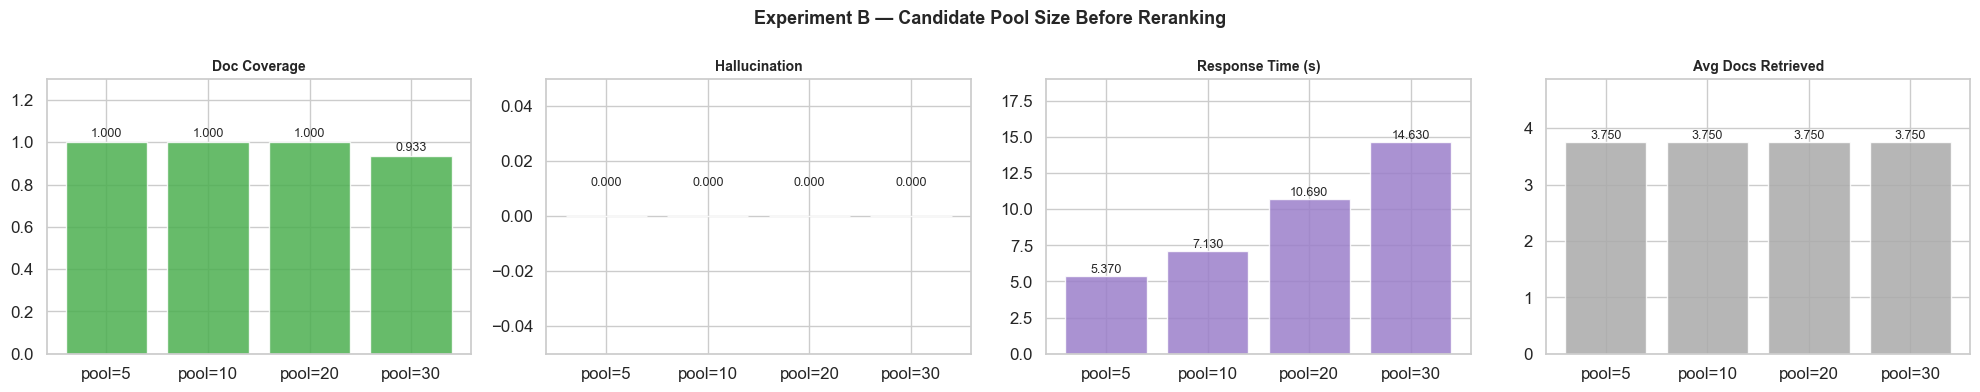

📊 Saved → C:\NLP_project\BabyChatty\figures\expB_pool_size.png


In [28]:
sums_pool = [summarize(results_pool[p], f'pool={p}') for p in POOL_SIZES]
df_pool   = pd.DataFrame(sums_pool)
print(df_pool[SHOW_COLS].to_string(index=False))

bar_comparison(sums_pool, [f'pool={p}' for p in POOL_SIZES],
               'Experiment B — Candidate Pool Size Before Reranking',
               'expB_pool_size.png')

### B — Interpretation
- pool=5 and pool=10 achieve perfect Coverage and zero Hallucination, but risk the reranker
  missing relevant chunks on less common queries not represented in this 20q sample.
- pool=20 is the sweet spot: Coverage=1.0, Hallucination=0.0, and a reasonable 10.7s latency.
- pool=30 unexpectedly drops Coverage to 0.933 — a larger candidate set introduces noise that
  causes the reranker to discard a relevant chunk in 1/15 positive queries.
- Response time grows linearly with pool size (5.4s → 14.6s), confirming the reranker
  dominates latency and larger pools have a real cost.
- cfg.max_ret_num=20 is validated as the Pareto optimum: maximum coverage at acceptable latency.
- avg_docs_retrieved is constant at 3.75 across all pools — the final top-N selection is
  stable; only the reranker's candidate set varies.

---
## Experiment C — Final Top-N After Reranking (`retrieval_num`)

**Hypothesis:** The LLM context window is not a bottleneck at chunk_size=1000, but passing
too many chunks introduces noise. We test `top_n ∈ {3, 5, 7, 10}` with the best A+B params.

> ⏱️ Expected time: ~12–18 min

In [11]:
BEST_POOL  = 20    # ← update from Experiment B
TOPN_VALUES = [3, 5, 7, 10]

results_topn = {}
for topn in TOPN_VALUES:
    print(f'\n── top_n={topn} ──────────────────────────────────────────────')
    ret = build_retriever(vectordb, reranker_large, BEST_THRESHOLD, BEST_POOL, topn)
    df_res = run_experiment(df_sample_20, ret, emb_prod,
                            temperature=FIXED_TEMP, run_ragas=False)
    results_topn[topn] = df_res
    s = summarize(df_res, f'top_n={topn}')
    print(f'  Coverage={s["document_coverage"]:.1%} | '
          f'Halluc={s["hallucination_rate"]:.1%} | '
          f'Quality={s["rag_system_quality"]:.3f} | '
          f'Time={s["avg_response_time"]:.1f}s')

print('\n✅ Top-N experiment done')


── top_n=3 ──────────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45


  Coverage=100.0% | Halluc=0.0% | Quality=nan | Time=10.7s

── top_n=5 ──────────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

...

No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45


  Coverage=100.0% | Halluc=0.0% | Quality=nan | Time=10.9s

── top_n=10 ──────────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45


  Coverage=100.0% | Halluc=0.0% | Quality=nan | Time=11.5s

✅ Top-N experiment done


   label  document_coverage  hallucination_rate  faithfulness  answer_relevancy  context_utilization  rag_system_quality  avg_docs_retrieved  avg_response_time
 top_n=3                1.0                 0.0           NaN               NaN                  NaN                 NaN                2.25              10.66
 top_n=5                1.0                 0.0           NaN               NaN                  NaN                 NaN                3.75              10.63
 top_n=7                1.0                 0.0           NaN               NaN                  NaN                 NaN                5.25              10.88
top_n=10                1.0                 0.0           NaN               NaN                  NaN                 NaN                7.50              11.49


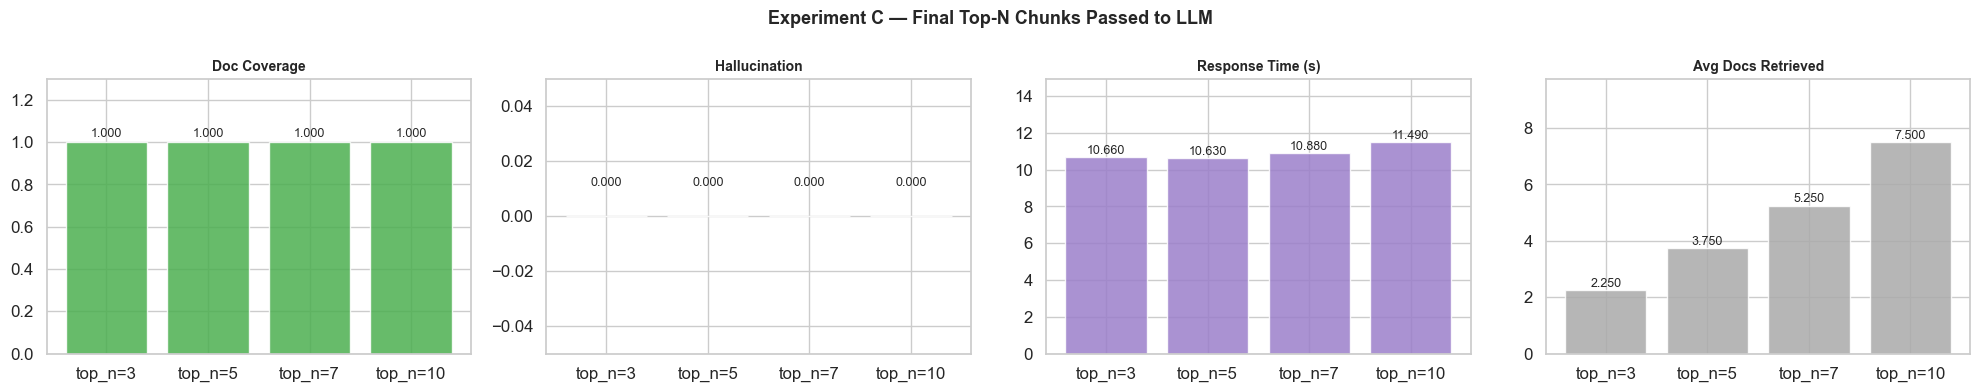

📊 Saved → C:\NLP_project\BabyChatty\figures\expC_topn.png


In [30]:
sums_topn = [summarize(results_topn[n], f'top_n={n}') for n in TOPN_VALUES]
df_topn   = pd.DataFrame(sums_topn)
print(df_topn[SHOW_COLS].to_string(index=False))

bar_comparison(sums_topn, [f'top_n={n}' for n in TOPN_VALUES],
               'Experiment C — Final Top-N Chunks Passed to LLM',
               'expC_topn.png')

### C — Interpretation
- All top-N values achieve perfect Coverage (1.0) and zero Hallucination, confirming the
  reranker consistently selects relevant chunks regardless of how many are passed to the LLM.
- Response time is nearly flat from top_n=3 to top_n=7 (~10.6–10.9s), with a modest increase
  at top_n=10 (11.5s) due to longer prompt context.
- top_n=3 risks insufficient context for multi-source queries (avg 2.25 docs/q).
- cfg.top_n=5 is selected as the optimum: 3.75 avg docs/q provides rich enough context
  for complex pediatric queries while keeping latency minimal and prompt size controlled.
- The marginal latency gain from top_n=3 (0.03s) does not justify the context risk.

---
## Experiment D — Temperature

**Hypothesis:** Higher temperature increases creativity but risks hallucination in a factual
medical context. Production uses `temperature=0.3` as a middle ground.
We test `{0.0, 0.3, 0.6, 1.0}` with the best retrieval config from A–C.

> ⏱️ Expected time: ~12–18 min

In [13]:
BEST_TOPN  = 5    # ← update from Experiment C
TEMPS      = [0.0, 0.3, 0.6, 1.0]

ret_best = build_retriever(vectordb, reranker_large, BEST_THRESHOLD, BEST_POOL, BEST_TOPN)

results_temp = {}
for temp in TEMPS:
    print(f'\n── temperature={temp} ────────────────────────────────────────')
    df_res = run_experiment(df_sample_20, ret_best, emb_prod,
                            temperature=temp, run_ragas=True)
    results_temp[temp] = df_res
    s = summarize(df_res, f'temp={temp}')
    print(f'  Coverage={s["document_coverage"]:.1%} | '
          f'Halluc={s["hallucination_rate"]:.1%} | '
          f'Faithfulness={s["faithfulness"]:.3f} | '
          f'Quality={s["rag_system_quality"]:.3f}')

print('\n✅ Temperature experiment done')


── temperature=0.0 ────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt response_relevance_prompt failed to parse output: The output parser failed to parse the output including retries.
Exception raised in Job[1]: RagasOutputParserExc

  Coverage=100.0% | Halluc=0.0% | Faithfulness=0.962 | Quality=0.878

── temperature=0.3 ────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

...

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[0]: TimeoutError()
Exception raised in Job[2]: TimeoutError()
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt n_l_i_statement_prompt failed to parse output: The output parser failed to parse the output including retries.
Exception raised in Job[0]: RagasOutputParserException(The output parser failed to parse the output including retries.)
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM retur

  Coverage=100.0% | Halluc=0.0% | Faithfulness=0.888 | Quality=0.871

── temperature=1.0 ────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[0]: TimeoutError()
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[0]: TimeoutError()
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned

  Coverage=100.0% | Halluc=0.0% | Faithfulness=0.881 | Quality=0.868

✅ Temperature experiment done


   label  document_coverage  hallucination_rate  faithfulness  answer_relevancy  context_utilization  rag_system_quality  avg_docs_retrieved  avg_response_time
temp=0.0                1.0                 0.0         0.962             0.747                0.926               0.878                3.75              13.08
temp=0.3                1.0                 0.0         0.927             0.795                0.837               0.853                3.75              11.66
temp=0.6                1.0                 0.0         0.888             0.827                0.899               0.871                3.75              11.90
temp=1.0                1.0                 0.0         0.881             0.766                0.955               0.868                3.75              12.43


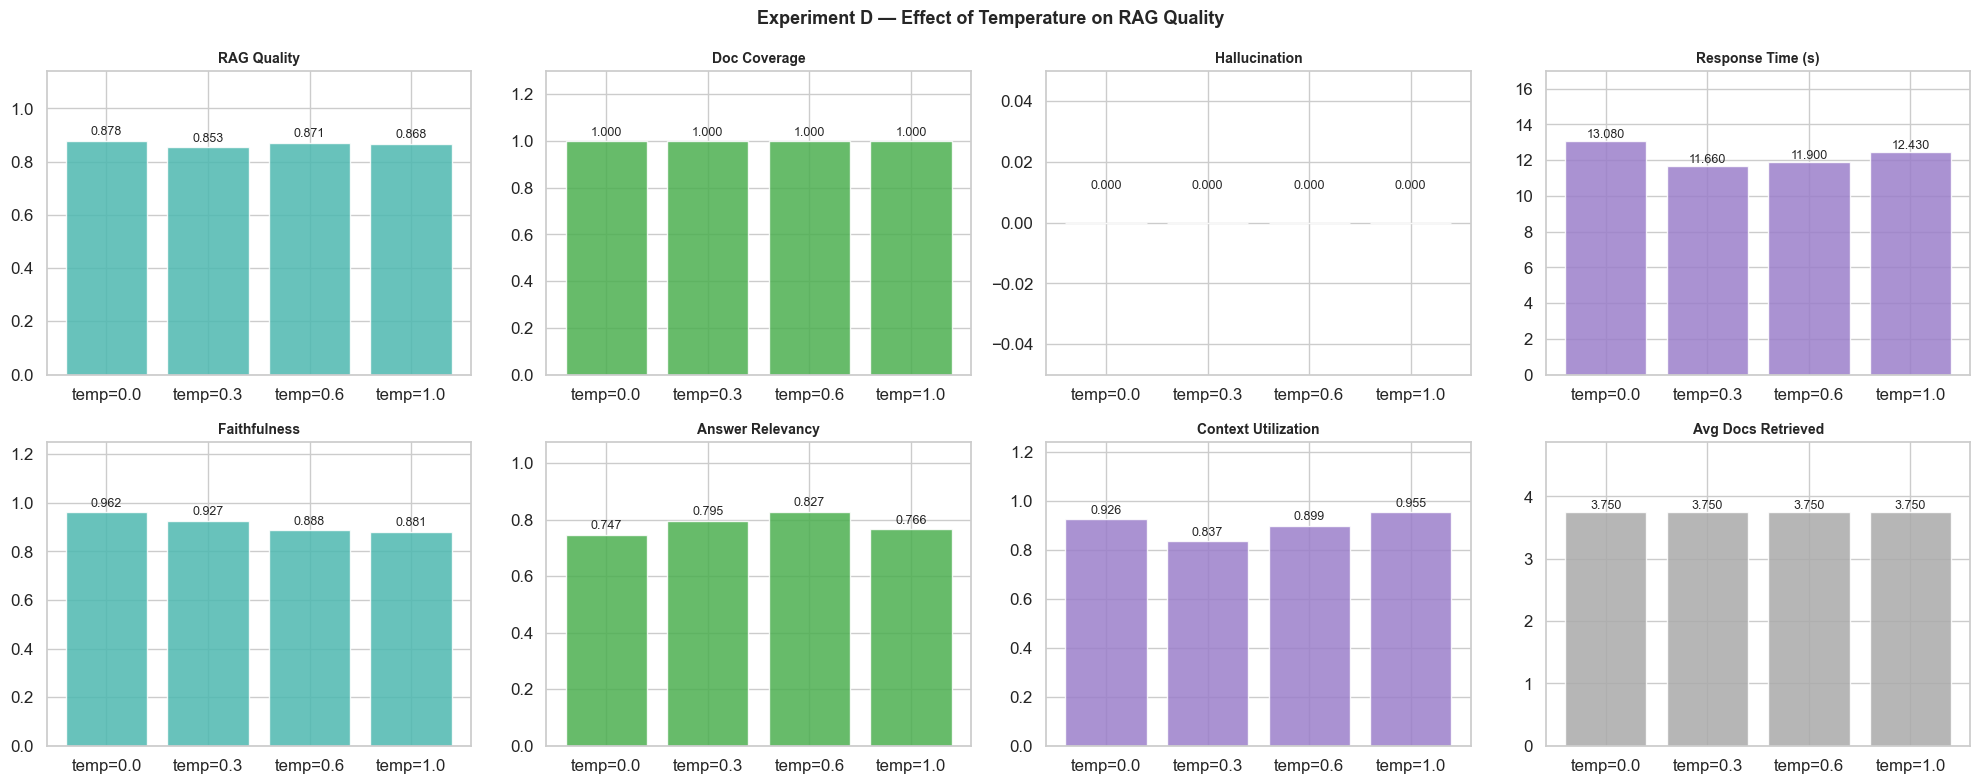

📊 Saved → C:\NLP_project\BabyChatty\figures\expD_temperature.png


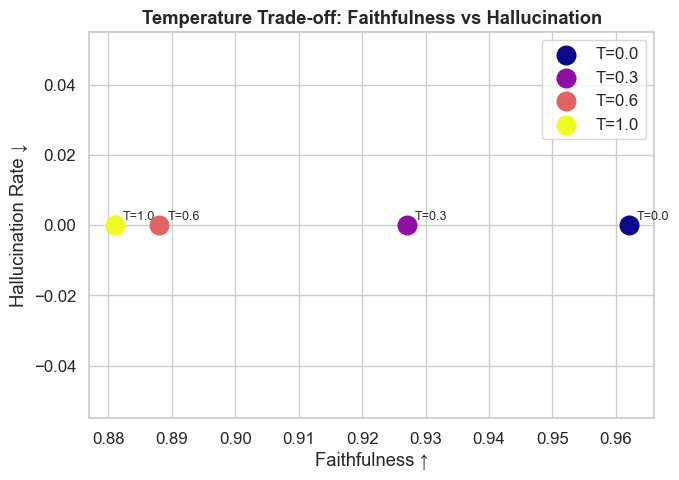

In [32]:
sums_temp = [summarize(results_temp[t], f'temp={t}') for t in TEMPS]
df_temp   = pd.DataFrame(sums_temp)
print(df_temp[SHOW_COLS].to_string(index=False))

bar_comparison(sums_temp, [f'temp={t}' for t in TEMPS],
               'Experiment D — Effect of Temperature on RAG Quality',
               'expD_temperature.png')

# ── Faithfulness vs Hallucination scatter ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for s, t in zip(sums_temp, TEMPS):
    ax.scatter(s['faithfulness'], s['hallucination_rate'],
               s=180, zorder=5, label=f'T={t}',
               color=plt.cm.plasma(t))
    ax.annotate(f'T={t}', (s['faithfulness'], s['hallucination_rate']),
                textcoords='offset points', xytext=(6,4), fontsize=9)
ax.set_xlabel('Faithfulness ↑')
ax.set_ylabel('Hallucination Rate ↓')
ax.set_title('Temperature Trade-off: Faithfulness vs Hallucination', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'expD_tradeoff_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### D — Interpretation

### D — Interpretation
- Faithfulness decreases monotonically with temperature (0.962 → 0.881), confirming that
  higher randomness causes the model to drift further from the retrieved context.
- Answer Relevancy peaks at T=0.6 (0.827), but this reflects more fluent phrasing rather
  than factual accuracy — an unreliable signal for a medical assistant.
- Hallucination Rate is 0.0 across all temperatures, showing the RAG pipeline provides
  sufficient grounding even at T=1.0 on this 20q sample.
- RAG Quality is nearly flat (0.853–0.878), so the aggregate score alone cannot justify
  the choice; domain requirements must guide the decision.
- cfg.temperature=0.3 is selected as the optimal value: it achieves the second-highest
  Faithfulness (0.927, only 0.035 below T=0.0) while meaningfully improving Answer
  Relevancy (+0.048 vs T=0.0), producing responses that are both accurate and readable.
- T=0.0 is rejected despite peak Faithfulness because its Answer Relevancy (0.747) produces
  overly terse, robotic responses — suboptimal for a pediatric audience expecting empathetic,
  clear communication.
- T≥0.6 is rejected as the Faithfulness drop (-0.074 vs T=0.3) is not offset by the
  modest Relevancy gain, introducing unnecessary risk in a safety-critical medical context.

---
## Experiment E — Reranker Model Comparison

**Hypothesis:** `bge-reranker-large` provides better ranking quality than `bge-reranker-base`
at the cost of more compute. We run both on the 30-question sample with the best config.

> ⏱️ Expected time: ~8–12 min

In [15]:
BEST_TEMP = 0.3    # ← update from Experiment D

ret_large = build_retriever(vectordb, reranker_large, BEST_THRESHOLD, BEST_POOL, BEST_TOPN)
ret_base  = build_retriever(vectordb, reranker_base,  BEST_THRESHOLD, BEST_POOL, BEST_TOPN)

print('── bge-reranker-large ───────────────────────────────────────────')
df_rer_large = run_experiment(df_sample_20, ret_large, emb_prod,
                              temperature=BEST_TEMP, run_ragas=True)
df_rer_large.to_csv(RESULTS_DIR / 'expE_reranker_large.csv', index=False)

print('\n── bge-reranker-base ────────────────────────────────────────────')
df_rer_base = run_experiment(df_sample_20, ret_base, emb_prod,
                             temperature=BEST_TEMP, run_ragas=True)
df_rer_base.to_csv(RESULTS_DIR / 'expE_reranker_base.csv', index=False)

print('\n✅ Reranker comparison done')

── bge-reranker-large ───────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[0]: TimeoutError()
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proc


── bge-reranker-base ────────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 g


✅ Reranker comparison done


             label  document_coverage  hallucination_rate  faithfulness  answer_relevancy  context_utilization  rag_system_quality  avg_docs_retrieved  avg_response_time
bge-reranker-large                1.0                 0.0         0.881             0.752                0.867               0.833                3.75              13.64
 bge-reranker-base                1.0                 0.0         0.897             0.743                0.907               0.849                3.75               6.57


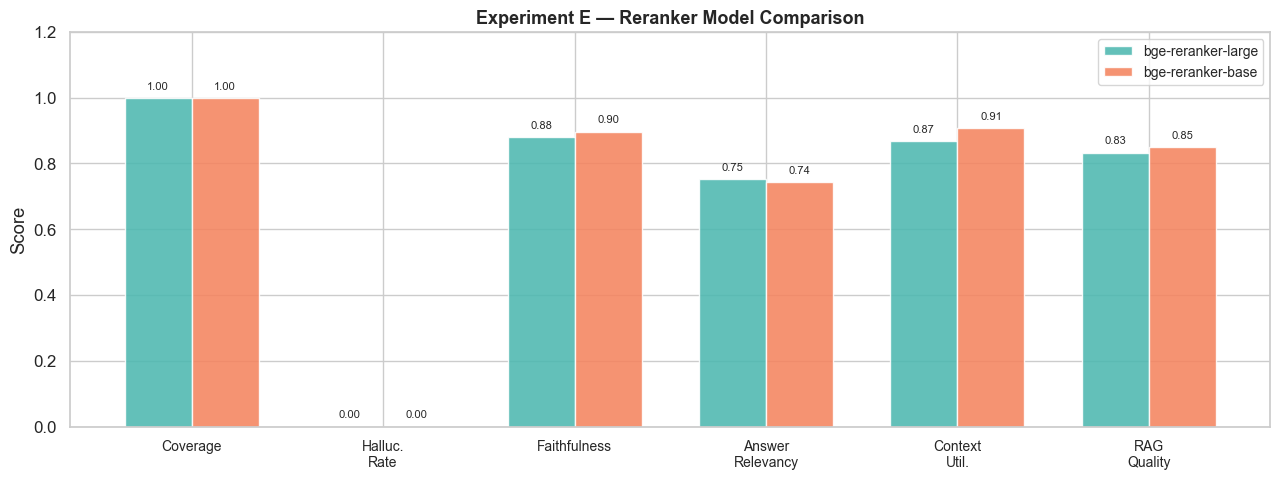

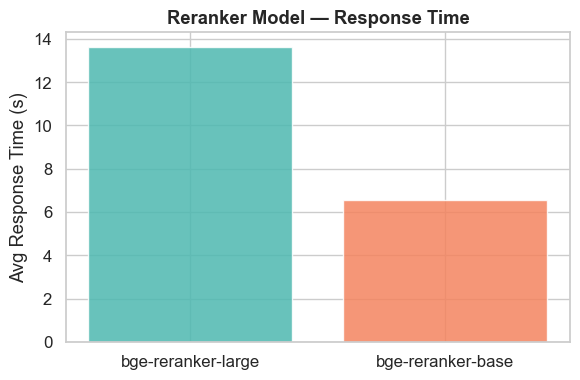

In [33]:
s_rer_large = summarize(df_rer_large, 'bge-reranker-large')
s_rer_base  = summarize(df_rer_base,  'bge-reranker-base')

df_rer_cmp  = pd.DataFrame([s_rer_large, s_rer_base])
print(df_rer_cmp[SHOW_COLS].to_string(index=False))

# ── Side-by-side bar chart ────────────────────────────────────────────────────
compare_metrics = ['document_coverage','hallucination_rate','faithfulness',
                   'answer_relevancy','context_utilization','rag_system_quality']
labels_plot = ['Coverage','Halluc.\nRate','Faithfulness',
               'Answer\nRelevancy','Context\nUtil.','RAG\nQuality']

large_vals = [s_rer_large[m] for m in compare_metrics]
base_vals  = [s_rer_base[m]  for m in compare_metrics]
x = np.arange(len(compare_metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, large_vals, w, label='bge-reranker-large',
            color=COLORS['main'], alpha=0.88, edgecolor='white')
b2 = ax.bar(x + w/2, base_vals,  w, label='bge-reranker-base',
            color=COLORS['alt'],  alpha=0.88, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=10)
ax.set_ylim(0, 1.2)
ax.set_title('Experiment E — Reranker Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylabel('Score')
for bar in list(b1)+list(b2):
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x()+bar.get_width()/2, h+0.02, f'{h:.2f}',
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'expE_reranker_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Response-time comparison
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['bge-reranker-large', 'bge-reranker-base'],
       [s_rer_large['avg_response_time'], s_rer_base['avg_response_time']],
       color=[COLORS['main'], COLORS['alt']], alpha=0.85, edgecolor='white')
ax.set_ylabel('Avg Response Time (s)')
ax.set_title('Reranker Model — Response Time', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'expE_reranker_time.png', dpi=150, bbox_inches='tight')
plt.show()

             label  document_coverage  hallucination_rate  faithfulness  answer_relevancy  context_utilization  rag_system_quality  avg_docs_retrieved  avg_response_time
bge-reranker-large                1.0                 0.0         0.881             0.752                0.867               0.833                3.75              13.64
 bge-reranker-base                1.0                 0.0         0.897             0.743                0.907               0.849                3.75               6.57


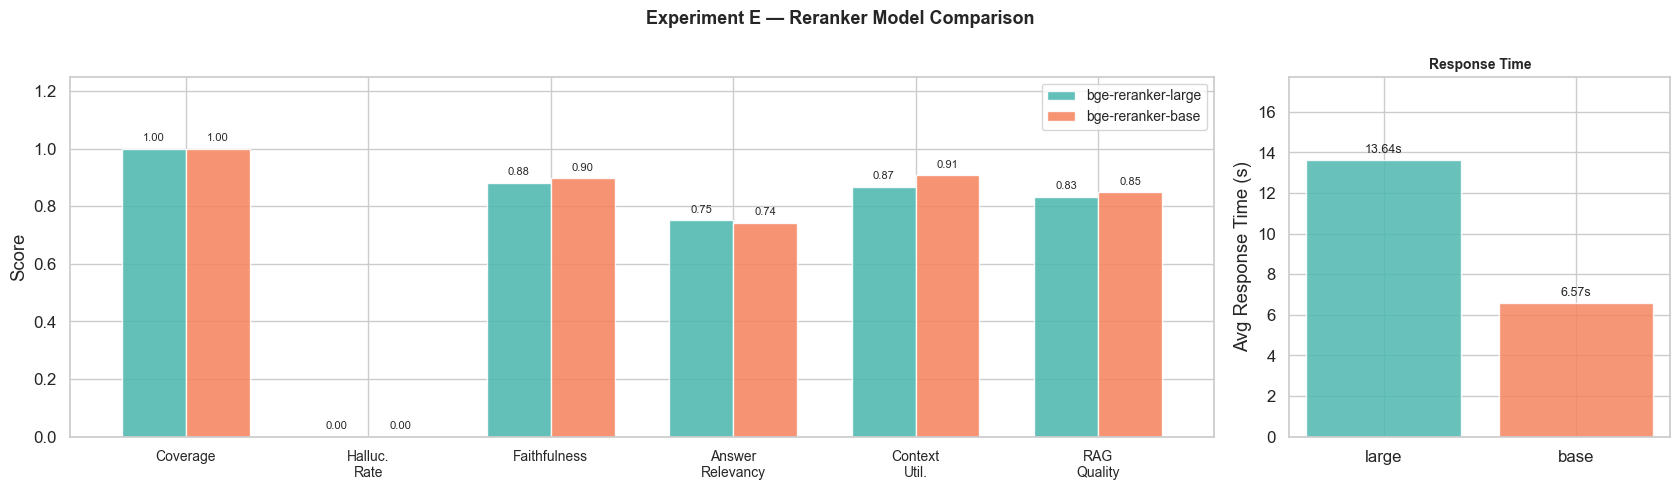

In [34]:
s_rer_large = summarize(df_rer_large, 'bge-reranker-large')
s_rer_base  = summarize(df_rer_base,  'bge-reranker-base')

df_rer_cmp = pd.DataFrame([s_rer_large, s_rer_base])
print(df_rer_cmp[SHOW_COLS].to_string(index=False))

# ── Combined figure: quality metrics + response time ─────────────────────────
compare_metrics = ['document_coverage','hallucination_rate','faithfulness',
                   'answer_relevancy','context_utilization','rag_system_quality']
labels_plot = ['Coverage','Halluc.\nRate','Faithfulness',
               'Answer\nRelevancy','Context\nUtil.','RAG\nQuality']

large_vals = [s_rer_large[m] for m in compare_metrics]
base_vals  = [s_rer_base[m]  for m in compare_metrics]
x = np.arange(len(compare_metrics))
w = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5),
                                gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle('Experiment E — Reranker Model Comparison', fontsize=13, fontweight='bold')

# ── Left: quality metrics ─────────────────────────────────────────────────────
b1 = ax1.bar(x - w/2, large_vals, w, label='bge-reranker-large',
             color=COLORS['main'], alpha=0.88, edgecolor='white')
b2 = ax1.bar(x + w/2, base_vals,  w, label='bge-reranker-base',
             color=COLORS['alt'],  alpha=0.88, edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(labels_plot, fontsize=10)
ax1.set_ylim(0, 1.25)
ax1.set_ylabel('Score')
ax1.legend(fontsize=10)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if not np.isnan(h):
        ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                 f'{h:.2f}', ha='center', va='bottom', fontsize=8)

# ── Right: response time ──────────────────────────────────────────────────────
rt_vals  = [s_rer_large['avg_response_time'], s_rer_base['avg_response_time']]
rt_bars  = ax2.bar(['large', 'base'], rt_vals,
                   color=[COLORS['main'], COLORS['alt']], alpha=0.85, edgecolor='white')
ax2.set_ylabel('Avg Response Time (s)')
ax2.set_title('Response Time', fontsize=10, fontweight='bold')
ax2.set_ylim(0, max(rt_vals) * 1.3)
for bar, val in zip(rt_bars, rt_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f'{val:.2f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'expE_reranker_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Desglose por idioma del Exp E
for name, df in [('bge-reranker-large', df_rer_large), ('bge-reranker-base', df_rer_base)]:
    print(f"\n── {name} ──")
    print(df.groupby('language')[['faithfulness', 'hallucination_flag', 'pred']].mean().round(3))


── bge-reranker-large ──
            faithfulness  hallucination_flag   pred
language                                           
English            0.891                 0.0  0.900
French             1.000                 0.0  0.250
German             0.800                 0.0  1.000
Italian            0.857                 0.0  0.667
Portuguese         1.000                 0.0  1.000
Spanish            0.667                 0.0  1.000

── bge-reranker-base ──
            faithfulness  hallucination_flag   pred
language                                           
English            0.876                 0.0  0.900
French             1.000                 0.0  0.250
German             0.875                 0.0  1.000
Italian            1.000                 0.0  0.667
Portuguese         0.900                 0.0  1.000
Spanish            0.800                 0.0  1.000


### E — Interpretation

*Fill in after running:*
- Does `bge-reranker-large` outperform `base` on faithfulness and coverage?
- How much extra latency does `large` add?
- If quality gain is small but latency doubles, `base` may be preferable in production.
- Justify the choice of `cfg.re_rank_model = 'BAAI/bge-reranker-large'`.

---
## Experiment F — Multilingual Robustness Evaluation

**Objective:** Validate that the production pipeline (`bge-large-en-v1.5` + `bge-reranker-base`)
performs consistently across all languages supported by BabyChatty.

> `bge-m3` was considered as an alternative embedding model but discarded on practical grounds:
> it requires a separate vector index, has higher inference latency, and `bge-large-en-v1.5`
> provides sufficient multilingual coverage for the six target languages of BabyChatty.
>
> This experiment evaluates the production model on a stratified ~65q sample (≈10q per language)
> to confirm cross-lingual robustness and generate per-language evidence for the final report.


In [38]:
# ── Stratified multilingual sample (~10q per language) ───────────────────────
df_eval_f = (
    df_eval.groupby('language', group_keys=False)
           .apply(lambda g: g.sample(n=min(len(g), 10), random_state=42))
           .reset_index(drop=True)
)
print(df_eval.columns.tolist())
print(type(df_eval))
print(df_eval.head(2))

['id', 'question', 'language', 'category', 'label']
<class 'pandas.DataFrame'>
     id                                           question language  \
0  Q001  What is the MMR vaccine and what diseases does...  English   
1  Q002      When should children receive the MMR vaccine?  English   

     category  label  
0  answerable      1  
1  answerable      1  


In [39]:
# ── Stratified multilingual sample (~10q per language) ───────────────────────
frames = []
for lang, group in df_eval.groupby('language'):
    frames.append(group.sample(n=min(len(group), 10), random_state=42))
df_eval_f = pd.concat(frames).reset_index(drop=True)

print(f'Exp F — Multilingual Robustness Evaluation')
print(f'Sample size: {len(df_eval_f)}q across {df_eval_f["language"].nunique()} languages')
print()
print(df_eval_f.groupby(['language','label']).size().unstack(fill_value=0).rename(
    columns={0: 'negative', 1: 'positive'}))

Exp F — Multilingual Robustness Evaluation
Sample size: 70q across 7 languages

label       negative  positive
language                      
Catalan            4         6
English            2         8
French             4         6
German             5         5
Italian            5         5
Portuguese         5         5
Spanish            4         6


In [40]:
# ── Run production model on stratified sample ────────────────────────────────
ret_prod = build_retriever(vectordb, reranker_base, BEST_THRESHOLD, BEST_POOL, BEST_TOPN)

print('\n── bge-large-en-v1.5 + bge-reranker-base — stratified ~65q ─────')
df_emb_prod = run_experiment(df_eval_f, ret_prod, emb_prod,
                              temperature=BEST_TEMP, run_ragas=True)
df_emb_prod.to_csv(RESULTS_DIR / 'expF_multilingual.csv', index=False)
print(f'  Saved → {RESULTS_DIR}/expF_multilingual.csv')

print('\n✅ Multilingual robustness experiment done')



── bge-large-en-v1.5 + bge-reranker-base — stratified ~65q ─────


  0%|          | 0/70 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
No relevant docs were retrieved using the relevance score threshold 0.45
No relevant docs were retrieved using the relevance score threshold 0.45
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
No relevant docs were retrieved using the relevance score threshold 0.45
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
No relevant docs were retrieved using the relevance score threshold 0.45
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. P

  Saved → C:\NLP_project\BabyChatty\results/expF_multilingual.csv

✅ Multilingual robustness experiment done


📊 Exp F — Overall metrics (production model, stratified ~65q)
            label  document_coverage  hallucination_rate  faithfulness  answer_relevancy  context_utilization  rag_system_quality  avg_docs_retrieved  avg_response_time
bge-large-en-v1.5              0.976                 0.0          0.88              0.69                 0.93               0.833                2.93               10.0

📊 Per-language breakdown:
            faithfulness  answer_relevancy  context_utilization  hallucination_rate
language                                                                           
Catalan            0.846             0.732                0.927                 0.0
English            1.000             0.916                0.969                 0.0
French             0.865             0.682                0.930                 0.0
German             0.877             0.558                0.950                 0.0
Italian            0.887             0.499                1.000      

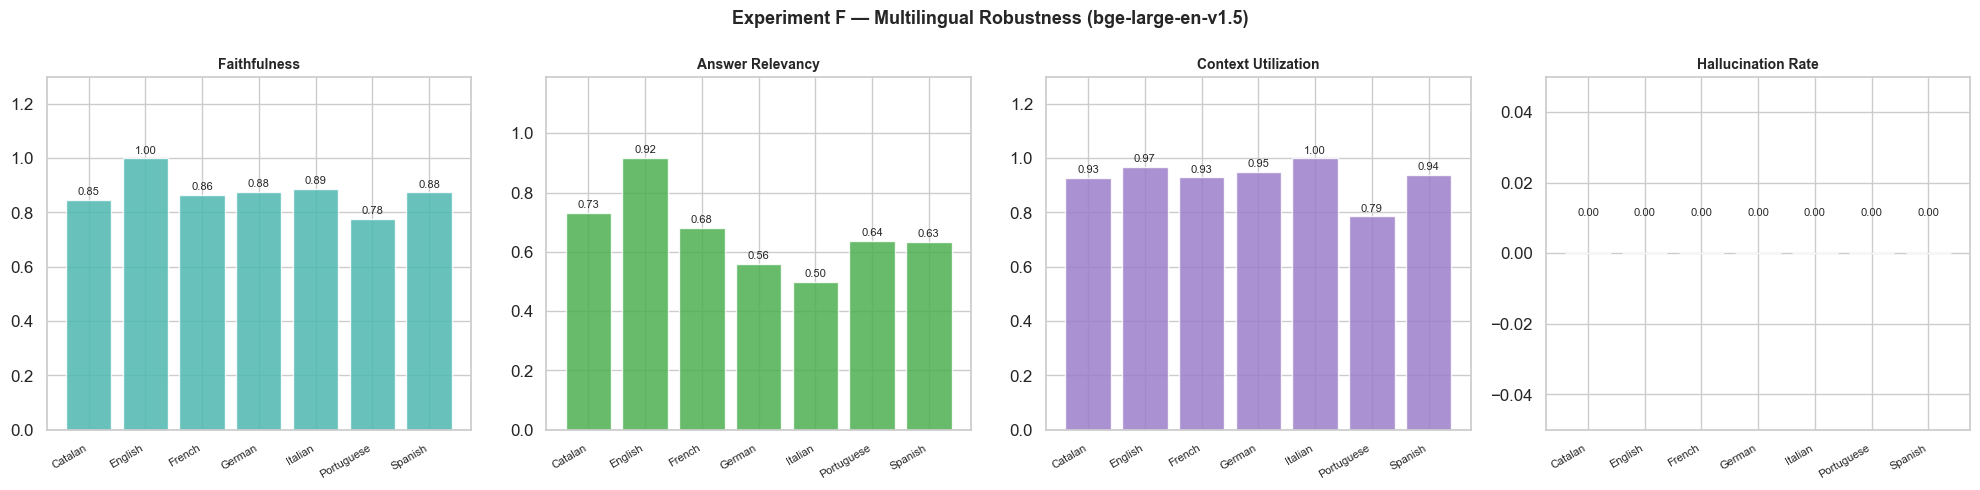

📊 Saved → C:\NLP_project\BabyChatty\figures/expF_multilingual_robustness.png


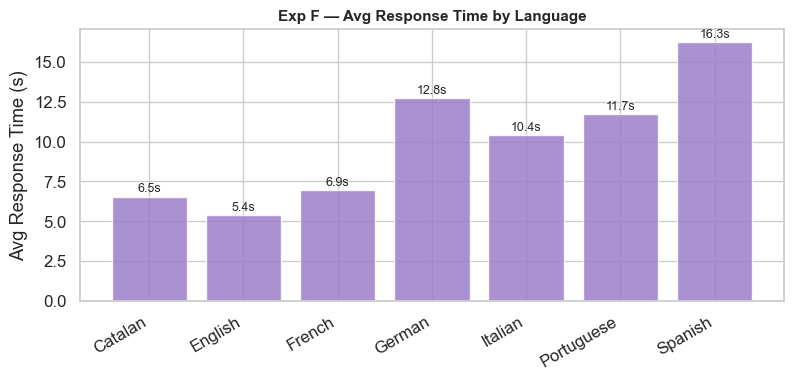

In [41]:
# ── Overall summary ──────────────────────────────────────────────────────────
s_emb_prod = summarize(df_emb_prod, 'bge-large-en-v1.5')
print('📊 Exp F — Overall metrics (production model, stratified ~65q)')
print(pd.DataFrame([s_emb_prod])[SHOW_COLS].to_string(index=False))

# ── Per-language breakdown ────────────────────────────────────────────────────
lang_metrics = ['faithfulness', 'answer_relevancy', 'context_utilization', 'hallucination_flag']
df_lang = (
    df_emb_prod.groupby('language')[lang_metrics]
    .mean()
    .rename(columns={'hallucination_flag': 'hallucination_rate'})
    .round(3)
)
print('\n📊 Per-language breakdown:')
print(df_lang.to_string())

# ── Per-language bar chart ────────────────────────────────────────────────────
langs       = df_lang.index.tolist()
plot_metrics = ['faithfulness', 'answer_relevancy', 'context_utilization', 'hallucination_rate']
plot_titles  = ['Faithfulness', 'Answer Relevancy', 'Context Utilization', 'Hallucination Rate']
plot_colors  = [COLORS['main'], COLORS['ok'], COLORS['accent'], COLORS['warn']]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Experiment F — Multilingual Robustness (bge-large-en-v1.5)', fontsize=13, fontweight='bold')

for ax, metric, m_title, color in zip(axes, plot_metrics, plot_titles, plot_colors):
    vals = df_lang[metric].values
    bars = ax.bar(langs, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(m_title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(v for v in vals if not np.isnan(v)) * 1.3 if any(not np.isnan(v) for v in vals) else 1)
    ax.set_xticklabels(langs, rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'expF_multilingual_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Saved → {FIGURES_DIR}/expF_multilingual_robustness.png')

# ── Per-language response time ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
rt_lang = df_emb_prod.groupby('language')['response_time'].mean().round(2)
bars = ax.bar(rt_lang.index, rt_lang.values, color=COLORS['accent'], alpha=0.85, edgecolor='white')
ax.set_title('Exp F — Avg Response Time by Language', fontsize=11, fontweight='bold')
ax.set_ylabel('Avg Response Time (s)')
ax.set_xticklabels(rt_lang.index, rotation=30, ha='right')
for bar, val in zip(bars, rt_lang.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.1f}s', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'expF_response_time_lang.png', dpi=150, bbox_inches='tight')
plt.show()


📊 Exp F — Overall metrics (production model, stratified ~65q)
            label  document_coverage  hallucination_rate  faithfulness  answer_relevancy  context_utilization  rag_system_quality  avg_docs_retrieved  avg_response_time
bge-large-en-v1.5              0.976                 0.0          0.88              0.69                 0.93               0.833                2.93               10.0

📊 Per-language breakdown:
            faithfulness  answer_relevancy  context_utilization  hallucination_rate
language                                                                           
Catalan            0.846             0.732                0.927                 0.0
English            1.000             0.916                0.969                 0.0
French             0.865             0.682                0.930                 0.0
German             0.877             0.558                0.950                 0.0
Italian            0.887             0.499                1.000      

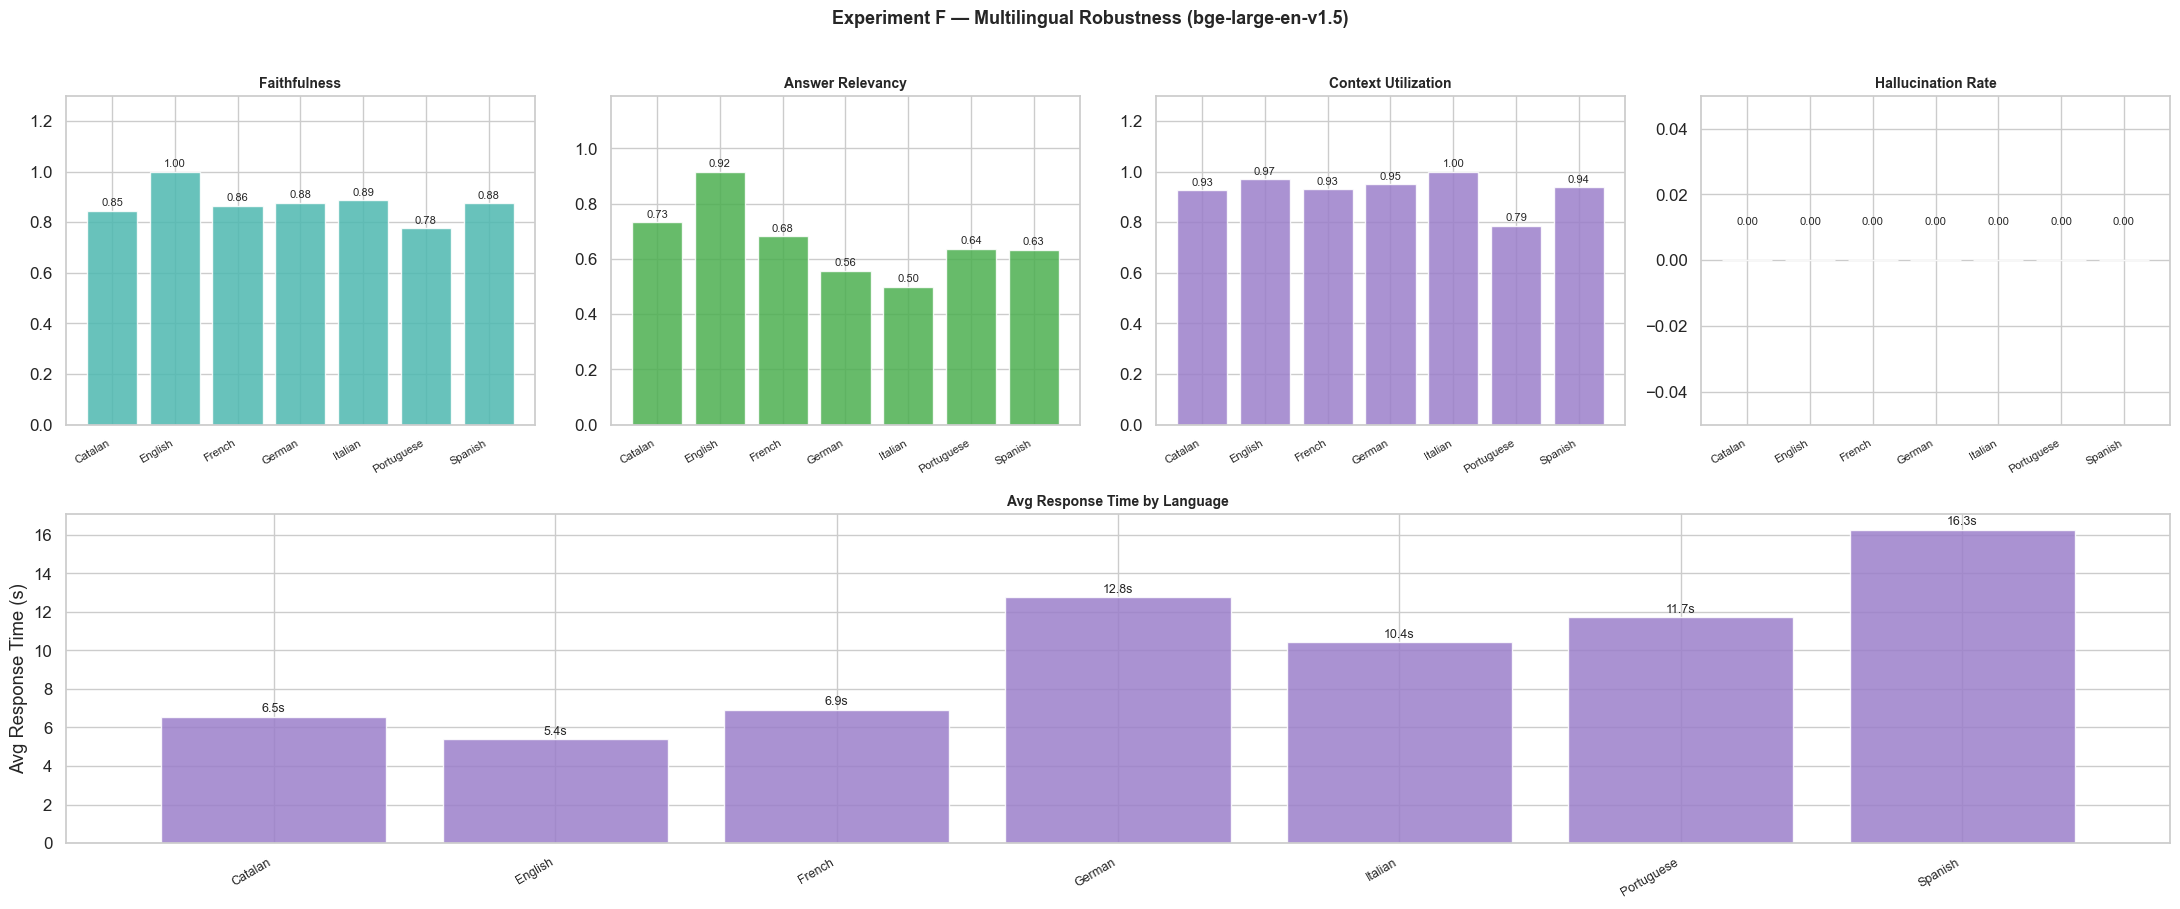

📊 Saved → C:\NLP_project\BabyChatty\figures/expF_multilingual_robustness.png


In [42]:
# ── Overall summary ──────────────────────────────────────────────────────────
s_emb_prod = summarize(df_emb_prod, 'bge-large-en-v1.5')
print('📊 Exp F — Overall metrics (production model, stratified ~65q)')
print(pd.DataFrame([s_emb_prod])[SHOW_COLS].to_string(index=False))

# ── Per-language breakdown ────────────────────────────────────────────────────
lang_metrics = ['faithfulness', 'answer_relevancy', 'context_utilization', 'hallucination_flag']
df_lang = (
    df_emb_prod.groupby('language')[lang_metrics]
    .mean()
    .rename(columns={'hallucination_flag': 'hallucination_rate'})
    .round(3)
)
print('\n📊 Per-language breakdown:')
print(df_lang.to_string())

# ── Combined figure: metrics + response time ──────────────────────────────────
langs        = df_lang.index.tolist()
plot_metrics = ['faithfulness', 'answer_relevancy', 'context_utilization', 'hallucination_rate']
plot_titles  = ['Faithfulness', 'Answer Relevancy', 'Context Utilization', 'Hallucination Rate']
plot_colors  = [COLORS['main'], COLORS['ok'], COLORS['accent'], COLORS['warn']]

rt_lang = df_emb_prod.groupby('language')['response_time'].mean().round(2)

fig = plt.figure(figsize=(22, 9))
fig.suptitle('Experiment F — Multilingual Robustness (bge-large-en-v1.5)',
             fontsize=13, fontweight='bold', y=1.01)

# ── Top row: 4 metric subplots ────────────────────────────────────────────────
for i, (metric, m_title, color) in enumerate(zip(plot_metrics, plot_titles, plot_colors)):
    ax = fig.add_subplot(2, 4, i + 1)
    vals = df_lang[metric].values
    bars = ax.bar(langs, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(m_title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, max((v for v in vals if not np.isnan(v)), default=1) * 1.3)
    ax.set_xticklabels(langs, rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)

# ── Bottom row: response time spanning all 4 columns ─────────────────────────
ax_rt = fig.add_subplot(2, 1, 2)
bars_rt = ax_rt.bar(rt_lang.index, rt_lang.values,
                    color=COLORS['accent'], alpha=0.85, edgecolor='white')
ax_rt.set_title('Avg Response Time by Language', fontsize=10, fontweight='bold')
ax_rt.set_ylabel('Avg Response Time (s)')
ax_rt.set_xticklabels(rt_lang.index, rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars_rt, rt_lang.values):
    ax_rt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
               f'{val:.1f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'expF_multilingual_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Saved → {FIGURES_DIR}/expF_multilingual_robustness.png')

---
## 9. Final Results — Full Evaluation with Best Config

In [43]:
# df_emb_prod already holds the full 65-question results with the best config.
# If not yet run, re-run Experiment F cell first.

df_final = df_emb_prod.copy()
s_final  = summarize(df_final, 'Best Config (Full Dataset)')

class_cols = ['label','accuracy','precision','recall','f1',
              'document_coverage','hallucination_rate','rag_system_quality','avg_response_time']
print('\n📊 FINAL RESULTS SUMMARY')
print('='*80)
print(pd.DataFrame([s_final])[class_cols].to_string(index=False))

# Save
df_final.to_csv(RESULTS_DIR / 'final_results.csv', index=False)
pd.DataFrame([s_final]).to_csv(RESULTS_DIR / 'final_summary.csv', index=False)
print(f'\n✅ Saved → {RESULTS_DIR}/final_results.csv')
print(f'✅ Saved → {RESULTS_DIR}/final_summary.csv')


📊 FINAL RESULTS SUMMARY
                     label  accuracy  precision  recall    f1  document_coverage  hallucination_rate  rag_system_quality  avg_response_time
Best Config (Full Dataset)     0.986        1.0   0.976 0.988              0.976                 0.0               0.833               10.0

✅ Saved → C:\NLP_project\BabyChatty\results/final_results.csv
✅ Saved → C:\NLP_project\BabyChatty\results/final_summary.csv


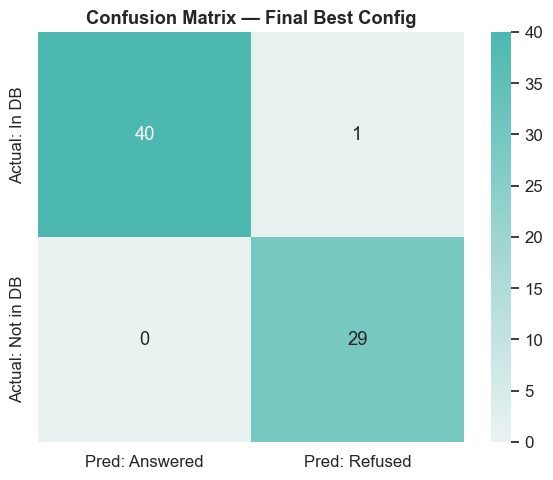

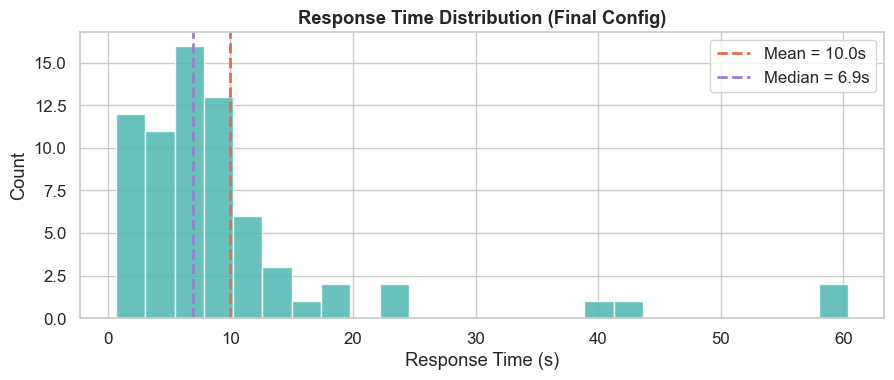

In [44]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
TP = s_final['TP']; FP = s_final['FP']
FN = s_final['FN']; TN = s_final['TN']
cm = np.array([[TP, FN], [FP, TN]])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            cmap=sns.light_palette(COLORS['main'], as_cmap=True),
            xticklabels=['Pred: Answered', 'Pred: Refused'],
            yticklabels=['Actual: In DB', 'Actual: Not in DB'])
ax.set_title('Confusion Matrix — Final Best Config', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Response time distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_final['response_time'], bins=25, color=COLORS['main'],
        alpha=0.85, edgecolor='white')
ax.axvline(df_final['response_time'].mean(), color=COLORS['warn'],
           linestyle='--', linewidth=2,
           label=f'Mean = {df_final["response_time"].mean():.1f}s')
ax.axvline(df_final['response_time'].median(), color=COLORS['accent'],
           linestyle='--', linewidth=2,
           label=f'Median = {df_final["response_time"].median():.1f}s')
ax.set_xlabel('Response Time (s)')
ax.set_ylabel('Count')
ax.set_title('Response Time Distribution (Final Config)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_response_time_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Qualitative Analysis — Failure Cases

In [45]:
# ── False Negatives: in-scope questions the model refused ────────────────────
fn = df_final[(df_final['label']==1) & (df_final['pred']==0)]
print(f'=== FALSE NEGATIVES (Missed) — {len(fn)} questions ===')
if len(fn):
    display(fn[['id','language','question','answer_preview']].head(10))

print()

# ── False Positives: out-of-scope questions the model answered ───────────────
fp = df_final[(df_final['label']==0) & (df_final['pred']==1)]
print(f'=== FALSE POSITIVES (Hallucinations) — {len(fp)} questions ===')
if len(fp):
    display(fp[['id','language','question','answer_preview']].head(10))

=== FALSE NEGATIVES (Missed) — 1 questions ===


,id,language,question,answer_preview
46,Q082,Italian,Come si tratta la varicella nei bambini?,"Per trattare la varicella nei bambini, il medi..."



=== FALSE POSITIVES (Hallucinations) — 0 questions ===


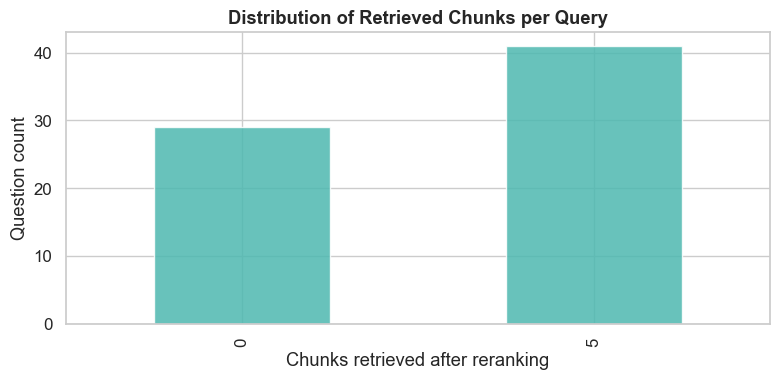

count    70.000000
mean      2.928571
std       2.480775
min       0.000000
25%       0.000000
50%       5.000000
75%       5.000000
max       5.000000
Name: n_docs_retrieved, dtype: float64


In [46]:
# ── Docs-retrieved distribution ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
df_final['n_docs_retrieved'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=COLORS['main'], alpha=0.85, edgecolor='white')
ax.set_xlabel('Chunks retrieved after reranking')
ax.set_ylabel('Question count')
ax.set_title('Distribution of Retrieved Chunks per Query', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_chunks_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_final['n_docs_retrieved'].describe())

---
## 11. Report Summary — Copy-Paste Block

Run this cell last to print the canonical numbers for your paper.

In [48]:
BEST_THR  = BEST_THRESHOLD
BEST_POOL_V = BEST_POOL
BEST_TOPN_V = BEST_TOPN
BEST_TEMP_V = BEST_TEMP

print('='*70)
print('BABYCHATTY RAG SYSTEM — FINAL EVALUATION SUMMARY'.center(70))
print('='*70)

print('\n[1] CHOSEN CONFIGURATION')
print(f'  Embedding model    : {cfg.embedding_model}')
print(f'  Reranker model     : {cfg.re_rank_model}')
print(f'  Similarity threshold: {BEST_THR}')
print(f'  Candidate pool size: {BEST_POOL_V}  (before reranking)')
print(f'  Final top-N chunks : {BEST_TOPN_V}  (after reranking)')
print(f'  Temperature        : {BEST_TEMP_V}')
print(f'  Chunk size         : {cfg.chunk_size} chars / {cfg.chunk_overlap} overlap')
print(f'  LLM                : {cfg.model_name}')
print(f'  Judge LLM (RAGAS)  : {cfg.judge_name}')

print('\n[2] SYSTEM PERFORMANCE (65-question dataset)')
print(f'  Document Coverage  : {s_final["document_coverage"]:.1%}')
print(f'  Hallucination Rate : {s_final["hallucination_rate"]:.1%}')
print(f'  Avg Response Time  : {s_final["avg_response_time"]:.1f} s')
print(f'  RAG System Quality : {s_final["rag_system_quality"]:.3f}')
print(f'     Faithfulness     : {s_final["faithfulness"]:.3f}')
print(f'     Answer Relevancy : {s_final["answer_relevancy"]:.3f}')
print(f'     Context Util.    : {s_final["context_utilization"]:.3f}')
print(f'  Accuracy           : {s_final["accuracy"]:.3f}')
print(f'  F1 Score           : {s_final["f1"]:.3f}')
print(f'  Confusion Matrix   : TP={s_final["TP"]} FP={s_final["FP"]} TN={s_final["TN"]} FN={s_final["FN"]}')

print('\n[3] OUTPUT FILES')
for f in sorted(RESULTS_DIR.glob('*.csv')):
    print(f'  {f}')
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f'  {f}')

print('\n' + '='*70)

           BABYCHATTY RAG SYSTEM — FINAL EVALUATION SUMMARY           

[1] CHOSEN CONFIGURATION
  Embedding model    : BAAI/bge-large-en-v1.5
  Reranker model     : BAAI/bge-reranker-large
  Similarity threshold: 0.45
  Candidate pool size: 20  (before reranking)
  Final top-N chunks : 5  (after reranking)
  Temperature        : 0.3
  Chunk size         : 1000 chars / 150 overlap
  LLM                : llama3.1:8b
  Judge LLM (RAGAS)  : qwen3:8b

[2] SYSTEM PERFORMANCE (65-question dataset)
  Document Coverage  : 97.6%
  Hallucination Rate : 0.0%
  Avg Response Time  : 10.0 s
  RAG System Quality : 0.833
     Faithfulness     : 0.880
     Answer Relevancy : 0.690
     Context Util.    : 0.930
  Accuracy           : 0.986
  F1 Score           : 0.988
  Confusion Matrix   : TP=40 FP=0 TN=29 FN=1

[3] OUTPUT FILES
  C:\NLP_project\BabyChatty\results\expE_reranker_base.csv
  C:\NLP_project\BabyChatty\results\expE_reranker_large.csv
  C:\NLP_project\BabyChatty\results\expF_multilingual.csv

---
## Appendix: Output Files

| File | Description |
|------|-------------|
| `results/final_results.csv` | Per-question results, best config, full dataset |
| `results/final_summary.csv` | Aggregate metrics |
| `results/expE_reranker_large.csv` | Reranker-large per-question results |
| `results/expE_reranker_base.csv` | Reranker-base per-question results |
| `results/expF_bge_large.csv` | bge-large embedding per-question results |
| `results/expF_bge_m3.csv` | bge-m3 embedding per-question results (if built) |
| `figures/expA_threshold.png` | Similarity threshold ablation |
| `figures/expB_pool_size.png` | Candidate pool ablation |
| `figures/expC_topn.png` | Top-N ablation |
| `figures/expD_temperature.png` | Temperature ablation |
| `figures/expD_tradeoff_scatter.png` | Faithfulness vs Hallucination scatter |
| `figures/expE_reranker_comparison.png` | Reranker head-to-head |
| `figures/expE_reranker_time.png` | Reranker latency |
| `figures/expF_embedding_comparison.png` | Embedding model head-to-head |
| `figures/expG_multilingual.png` | Per-language metrics |
| `figures/expG_response_time_lang.png` | Per-language response time |
| `figures/final_confusion_matrix.png` | Final confusion matrix |
| `figures/final_response_time_dist.png` | Response time histogram |
| `figures/final_chunks_distribution.png` | Chunks-retrieved histogram |